In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Setting root of the project to:", root)
print("This means we can bring in models from other directories (like ./models)")

# Read a single allele frequency, i.e., "0:200:0:1:0:0"
def alleleFrequency(base, allele_count):
    # Allele count format: [A : T : C : G : N : del]
    base_dict = {
        'A': 0,
        'T': 1,
        'C': 2,
        'G': 3,
        'N': 4,   # unused
        'del': 5  # unsued, both defined to be explicit
    }
    base_index = base_dict.get(base)
    vector = [int(num) for num in allele_count.split(':')]

    # Sum all values
    total = sum(vector)

    # Error-handle for division-by-zero
    if total == 0:
        return 0.0

    # Find difference between base & total
    base_value = vector[base_index]
    mutations = total - base_value
    freq = mutations / total
    return freq;
columns = [
    'chromosome',
    'position',
    'base',
    'Dsim_Fl_Base_1',
    'Dsim_Fl_Hot_F10_1',
    'Dsim_Fl_Hot_F20_1', 
    'Dsim_Fl_Hot_F30_1',
    'Dsim_Fl_Hot_F40_1', 
    'Dsim_Fl_Hot_F50_1', 
    'Dsim_Fl_Hot_F60_1'
]

real_df = pd.read_csv(
    filepath_or_buffer="../data/chromosome_2L.sync",
    sep='\t', # tab-separated values
    names=columns,
    usecols=columns,
    header=None # no headers provided
)

rename_dict = {
    'Dsim_Fl_Base_1':    'gen_0',
    'Dsim_Fl_Hot_F10_1': 'gen_10',
    'Dsim_Fl_Hot_F20_1': 'gen_20',
    'Dsim_Fl_Hot_F30_1': 'gen_30',
    'Dsim_Fl_Hot_F40_1': 'gen_40',
    'Dsim_Fl_Hot_F50_1': 'gen_50',
    'Dsim_Fl_Hot_F60_1': 'gen_60'
}

# Rename the columns (inplace=True modifies the original DataFrame)
real_df.drop(columns=['chromosome'], inplace=True)
real_df.rename(columns=rename_dict, inplace=True)

for column in ['gen_0','gen_10','gen_20','gen_30','gen_40','gen_50','gen_60']:
    real_df[column] = [
        alleleFrequency(b, c) 
        for b, c in zip(real_df['base'], real_df[column])
    ]    


Setting root of the project to: /home/kv/education/predicting_DFE
This means we can bring in models from other directories (like ./models)


In [2]:
real_df.head()

,position,base,gen_0,gen_10,gen_20,gen_30,gen_40,gen_50,gen_60
0,59,T,0.157895,0.227273,0.280702,0.238095,0.229167,0.216495,0.204819
1,62,A,0.156627,0.233333,0.262295,0.247191,0.222930,0.226415,0.195402
2,153,A,0.200000,0.194030,0.194737,0.261682,0.205882,0.176923,0.218750
3,207,G,0.109589,0.093750,0.086705,0.083333,0.093333,0.053030,0.124031
4,219,T,0.051948,0.071429,0.062500,0.063291,0.059055,0.083333,0.100000


In [4]:
starting_index = real_df[real_df.position > 1_000_000].index[0]
starting_loc = real_df.index.get_loc(starting_index)
positions = real_df.iloc[starting_loc : starting_loc + 70_000]
positions

,position,base,gen_0,gen_10,gen_20,gen_30,gen_40,gen_50,gen_60
30032,1000020,G,0.287425,0.327485,0.343750,0.321429,0.333333,0.342697,0.324022
30033,1000025,T,0.041420,0.045977,0.040724,0.018182,0.038298,0.035503,0.011050
30034,1000034,T,0.111842,0.114286,0.159624,0.197605,0.134783,0.113208,0.129213
30035,1000045,T,0.165563,0.127907,0.125000,0.162338,0.164557,0.169935,0.109091
30036,1000063,G,0.064935,0.059172,0.038298,0.046980,0.047059,0.034247,0.106509
...,...,...,...,...,...,...,...,...,...
100027,2458912,T,0.189055,0.098901,0.148789,0.120192,0.115282,0.110577,0.102439
100028,2458931,T,0.563107,0.580110,0.543253,0.638393,0.611732,0.591133,0.624365
100029,2458939,G,0.187500,0.158470,0.124161,0.129630,0.150418,0.166667,0.162437
100030,2458947,A,0.004651,0.010929,0.006645,0.008811,0.002725,0.004717,0.019417


In [5]:
dfl = positions.melt(
    id_vars=['position', 'base'],
    value_vars=['gen_0', 'gen_10', 'gen_20', 'gen_30', 'gen_40', 'gen_50', 'gen_60'],
    var_name='time',
    value_name='freq',
)
dfl['time'] = dfl['time'].str.replace("gen_", "").astype(int)
dfl

,position,base,time,freq
0,1000020,G,0,0.287425
1,1000025,T,0,0.041420
2,1000034,T,0,0.111842
3,1000045,T,0,0.165563
4,1000063,G,0,0.064935
...,...,...,...,...
489995,2458912,T,60,0.102439
489996,2458931,T,60,0.624365
489997,2458939,G,60,0.162437
489998,2458947,A,60,0.019417


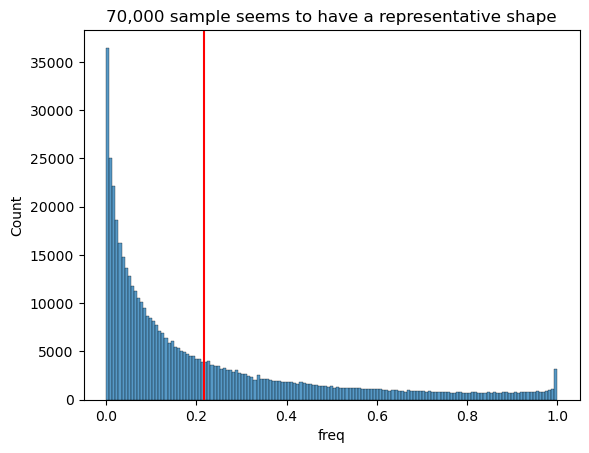

In [6]:
sns.histplot(data=dfl, x='freq')
plt.title("70,000 sample seems to have a representative shape")
plt.axvline(dfl['freq'].mean(), color='red')
plt.show()

In [22]:
# Save the sampled positions to a .csv
positions['position'].to_csv(
    "../slim/inputs/admixture_mapping_targets.csv", 
    header=False, 
    index=False
)

# Save a copy of the real allele frequencies for comparison later (saves some compute)
positions.to_csv("../slim/inputs/real_frequencies.csv", index=False)